# Model Comparison and Architecture Visualizations

This notebook verifies that the FULL and INTERMEDIATE CNN experiments are directly comparable, summarizes the validation-selected models, exports comparison tables, and generates architecture diagrams for the full CNN.

In [3]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import visualkeras

from IPython.display import display


def find_repository_root():
    current_path = Path.cwd().resolve()

    for candidate in (current_path, *current_path.parents):
        has_project = (candidate / "project").is_dir()
        has_datasets = (candidate / "datasets").is_dir()

        if has_project and has_datasets:
            return candidate

    raise FileNotFoundError(
        "Repository root not found. Expected 'project' and "
        "'datasets' directories in the same location."
    )


REPO_ROOT = find_repository_root()
PROJECT_DIR = REPO_ROOT / "project"

FULL_OUTPUT_DIR = PROJECT_DIR / "cnn_outputs"
INTERMEDIATE_OUTPUT_DIR = (
    PROJECT_DIR / "cnn_outputs_intermediate"
)

PRESENTATION_OUTPUT_DIR = (
    REPO_ROOT / "presentation_outputs"
)
FIGURES_DIR = PRESENTATION_OUTPUT_DIR / "figures"
TABLES_DIR = PRESENTATION_OUTPUT_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from utils import build_optimized_model


print(f"Repository root: {REPO_ROOT}")
print(f"Project directory: {PROJECT_DIR}")
print(f"Presentation outputs: {PRESENTATION_OUTPUT_DIR}")

Repository root: C:\Users\lollo\Documents\GitHub\deep-learning-wafer-defects
Project directory: C:\Users\lollo\Documents\GitHub\deep-learning-wafer-defects\project
Presentation outputs: C:\Users\lollo\Documents\GitHub\deep-learning-wafer-defects\presentation_outputs


## Experiment audit files

The audit files contain the dataset hashes, split hashes, selected-model metadata, validation metrics, test metrics, and model complexity information produced by the two experiment notebooks.

In [4]:
FULL_AUDIT_PATH = (
    FULL_OUTPUT_DIR
    / "audit"
    / "full_audit.json"
)

INTERMEDIATE_AUDIT_PATH = (
    INTERMEDIATE_OUTPUT_DIR
    / "audit"
    / "intermediate_audit.json"
)

audit_paths = {
    "FULL": FULL_AUDIT_PATH,
    "INTERMEDIATE": INTERMEDIATE_AUDIT_PATH,
}

for family_name, audit_path in audit_paths.items():
    print(
        f"{family_name} audit: "
        f"{audit_path.relative_to(REPO_ROOT)}"
    )
    print(f"Exists: {audit_path.exists()}")

    if not audit_path.exists():
        raise FileNotFoundError(
            f"Missing {family_name} audit file: "
            f"{audit_path}"
        )

with FULL_AUDIT_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    full_audit = json.load(file)

with INTERMEDIATE_AUDIT_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    intermediate_audit = json.load(file)

FULL audit: project\cnn_outputs\audit\full_audit.json
Exists: True
INTERMEDIATE audit: project\cnn_outputs_intermediate\audit\intermediate_audit.json
Exists: True


## Experiment consistency

The following checks confirm that both notebooks used the same dataset and exactly the same training, validation, and test partitions.

In [5]:
consistency_checks = pd.DataFrame(
    {
        "Check": [
            "Correct FULL family label",
            "Correct INTERMEDIATE family label",
            "Same dataset content",
            "Same dataset row count",
            "Same training indices",
            "Same validation indices",
            "Same test indices",
            "FULL checkpoint paths unique",
            "INTERMEDIATE checkpoint paths unique",
        ],
        "Passed": [
            full_audit["model_family"] == "FULL",
            (
                intermediate_audit["model_family"]
                == "INTERMEDIATE"
            ),
            (
                full_audit["dataset"]["sha256"]
                == intermediate_audit[
                    "dataset"
                ]["sha256"]
            ),
            (
                full_audit["dataset"]["number_of_rows"]
                == intermediate_audit[
                    "dataset"
                ]["number_of_rows"]
            ),
            (
                full_audit["splits"]["train"]["sha256"]
                == intermediate_audit[
                    "splits"
                ]["train"]["sha256"]
            ),
            (
                full_audit[
                    "splits"
                ]["validation"]["sha256"]
                == intermediate_audit[
                    "splits"
                ]["validation"]["sha256"]
            ),
            (
                full_audit["splits"]["test"]["sha256"]
                == intermediate_audit[
                    "splits"
                ]["test"]["sha256"]
            ),
            full_audit[
                "checkpoint_paths_are_unique"
            ],
            intermediate_audit[
                "checkpoint_paths_are_unique"
            ],
        ],
    }
)

display(consistency_checks)

if not consistency_checks["Passed"].all():
    failed_checks = consistency_checks.loc[
        ~consistency_checks["Passed"]
    ]

    raise AssertionError(
        "The FULL and INTERMEDIATE experiments are "
        "not directly comparable:\n"
        f"{failed_checks}"
    )

print(
    "The FULL and INTERMEDIATE experiments use "
    "the same dataset and identical data partitions."
)

,Check,Passed
0,Correct FULL family label,True
1,Correct INTERMEDIATE family label,True
2,Same dataset content,True
3,Same dataset row count,True
4,Same training indices,True
5,Same validation indices,True
6,Same test indices,True
7,FULL checkpoint paths unique,True
8,INTERMEDIATE checkpoint paths unique,True


The FULL and INTERMEDIATE experiments use the same dataset and identical data partitions.


## Validation-selected model comparison

Each architecture is represented by the model selected exclusively from validation Macro F1. Test metrics are reported only after model selection.

In [6]:
selected_model_comparison = pd.DataFrame(
    [
        {
            "Architecture": "INTERMEDIATE",
            "Selected model": (
                intermediate_audit[
                    "selected_model"
                ]["name"]
            ),
            "Conv filters": str(
                intermediate_audit[
                    "selected_model"
                ]["convolution_filters"]
            ),
            "Dense units": str(
                intermediate_audit[
                    "selected_model"
                ]["dense_units"]
            ),
            "Parameters": (
                intermediate_audit[
                    "selected_model"
                ]["total_parameters"]
            ),
            **{
                f"Validation {metric}": value
                for metric, value in intermediate_audit[
                    "selected_model"
                ]["validation_metrics"].items()
            },
            **{
                f"Test {metric}": value
                for metric, value in intermediate_audit[
                    "selected_model"
                ]["test_metrics"].items()
            },
        },
        {
            "Architecture": "FULL",
            "Selected model": (
                full_audit[
                    "selected_model"
                ]["name"]
            ),
            "Conv filters": str(
                full_audit[
                    "selected_model"
                ]["convolution_filters"]
            ),
            "Dense units": str(
                full_audit[
                    "selected_model"
                ]["dense_units"]
            ),
            "Parameters": (
                full_audit[
                    "selected_model"
                ]["total_parameters"]
            ),
            **{
                f"Validation {metric}": value
                for metric, value in full_audit[
                    "selected_model"
                ]["validation_metrics"].items()
            },
            **{
                f"Test {metric}": value
                for metric, value in full_audit[
                    "selected_model"
                ]["test_metrics"].items()
            },
        },
    ]
).set_index("Architecture")

metric_columns = [
    column
    for column in selected_model_comparison.columns
    if (
        column.startswith("Validation ")
        or column.startswith("Test ")
    )
]

display(
    selected_model_comparison.style.format(
        {
            **{
                column: "{:.2%}"
                for column in metric_columns
            },
            "Parameters": "{:,}",
        }
    )
)

,Selected model,Conv filters,Dense units,Parameters,Validation Accuracy,Validation Balanced Accuracy,Validation Macro Precision,Validation Macro Recall,Validation Macro F1,Test Accuracy,Test Balanced Accuracy,Test Macro Precision,Test Macro Recall,Test Macro F1
Architecture,,,,,,,,,,,,,,
INTERMEDIATE,Intermediate optimizer — SGD + Nesterov,"[24, 48, 96]","[96, 9]","505,449",95.97%,90.58%,81.76%,90.58%,85.64%,95.80%,85.33%,81.03%,85.33%,82.29%
FULL,Optimizer study — Nadam,"[32, 64, 128]","[128, 9]","897,673",96.01%,90.48%,81.77%,90.48%,85.64%,95.68%,87.32%,79.91%,87.32%,83.14%


In [7]:
intermediate_parameters = int(
    intermediate_audit[
        "selected_model"
    ]["total_parameters"]
)

full_parameters = int(
    full_audit[
        "selected_model"
    ]["total_parameters"]
)

parameter_reduction = (
    1
    - intermediate_parameters / full_parameters
)

print(
    "FULL parameters: "
    f"{full_parameters:,}"
)
print(
    "INTERMEDIATE parameters: "
    f"{intermediate_parameters:,}"
)
print(
    "Parameter reduction from FULL to INTERMEDIATE: "
    f"{parameter_reduction:.2%}"
)

if intermediate_parameters >= full_parameters:
    raise AssertionError(
        "The INTERMEDIATE model does not have fewer "
        "parameters than the FULL model."
    )

FULL parameters: 897,673
INTERMEDIATE parameters: 505,449
Parameter reduction from FULL to INTERMEDIATE: 43.69%


## Selected-model test performance

The comparison below focuses on balanced accuracy, Macro F1, and macro precision on the large test set.

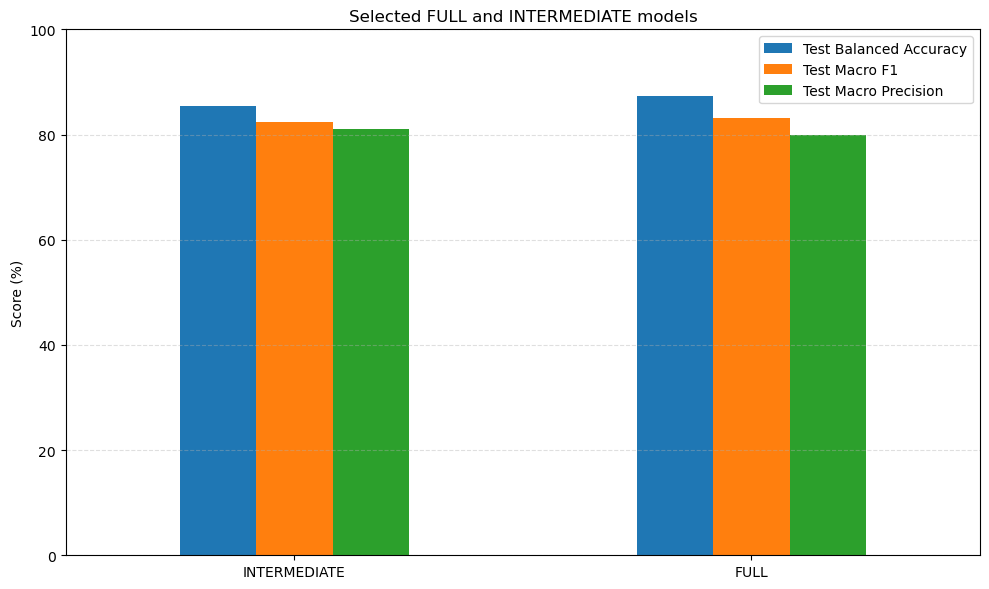

Comparison figure saved to: C:\Users\lollo\Documents\GitHub\deep-learning-wafer-defects\presentation_outputs\figures\selected_model_test_comparison.png


In [8]:
test_metric_comparison = (
    selected_model_comparison[
        [
            "Test Balanced Accuracy",
            "Test Macro F1",
            "Test Macro Precision",
        ]
    ]
    .mul(100)
)

axis = test_metric_comparison.plot(
    kind="bar",
    figsize=(10, 6),
)

axis.set_title(
    "Selected FULL and INTERMEDIATE models"
)
axis.set_xlabel("")
axis.set_ylabel("Score (%)")
axis.set_ylim(0, 100)
axis.grid(
    axis="y",
    linestyle="--",
    alpha=0.4,
)

plt.xticks(rotation=0)
plt.tight_layout()

comparison_figure_path = (
    FIGURES_DIR
    / "selected_model_test_comparison.png"
)

plt.savefig(
    comparison_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Comparison figure saved to: "
    f"{comparison_figure_path}"
)

## Exported comparison tables

The consistency checks and selected-model comparison are saved as CSV files for use in reports and presentations.

In [9]:
consistency_output_path = (
    TABLES_DIR
    / "experiment_consistency_checks.csv"
)

comparison_output_path = (
    TABLES_DIR
    / "selected_model_comparison.csv"
)

consistency_checks.to_csv(
    consistency_output_path,
    index=False,
)

selected_model_comparison.to_csv(
    comparison_output_path,
)

print(
    "Consistency checks saved to: "
    f"{consistency_output_path}"
)
print(
    "Selected-model comparison saved to: "
    f"{comparison_output_path}"
)

Consistency checks saved to: C:\Users\lollo\Documents\GitHub\deep-learning-wafer-defects\presentation_outputs\tables\experiment_consistency_checks.csv
Selected-model comparison saved to: C:\Users\lollo\Documents\GitHub\deep-learning-wafer-defects\presentation_outputs\tables\selected_model_comparison.csv


## Full CNN architecture

The optimizer does not affect the network structure. Adam is used here only to compile a representative instance of the full CNN for visualization.

In [10]:
full_architecture_model = build_optimized_model(
    use_he=True,
    use_l2=True,
    optimizer="adam",
    input_shape=(56, 56, 1),
    num_classes=9,
)

full_architecture_model.summary()

Model: "Wafer_CNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalize_discrete_values (  (None, 56, 56, 1)        0         
 Rescaling)                                                      
                                                                 
 conv_layer_1 (Conv2D)       (None, 56, 56, 32)        320       
                                                                 
 batch_norm_1 (BatchNormaliz  (None, 56, 56, 32)       128       
 ation)                                                          
                                                                 
 max_pool_1 (MaxPooling2D)   (None, 28, 28, 32)        0         
                                                                 
 conv_layer_2 (Conv2D)       (None, 28, 28, 64)        18496     
                                                                 
 batch_norm_2 (BatchNormaliz  (None, 28, 28, 64)       25

### Layer-volume representation

c:\Users\lollo\anaconda3\envs\data_science\lib\site-packages\visualkeras\layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


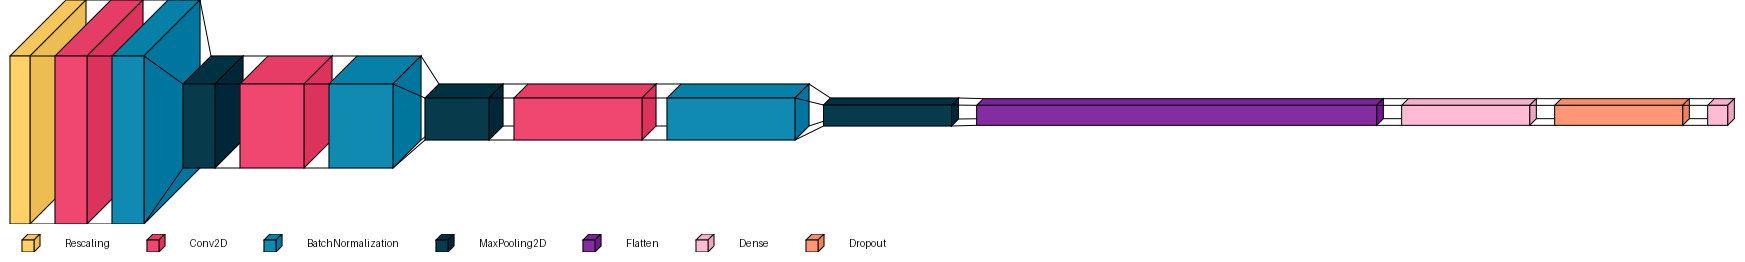

Architecture diagram saved to: C:\Users\lollo\Documents\GitHub\deep-learning-wafer-defects\presentation_outputs\figures\cnn_architecture_hd.png


In [11]:
architecture_hd_path = (
    FIGURES_DIR
    / "cnn_architecture_hd.png"
)

architecture_hd = visualkeras.layered_view(
    full_architecture_model,
    legend=True,
    draw_volume=True,
    scale_xy=3,
    scale_z=1,
    spacing=25,
    to_file=str(architecture_hd_path),
)

display(architecture_hd)

print(
    "Architecture diagram saved to: "
    f"{architecture_hd_path}"
)

### Layer dimensions

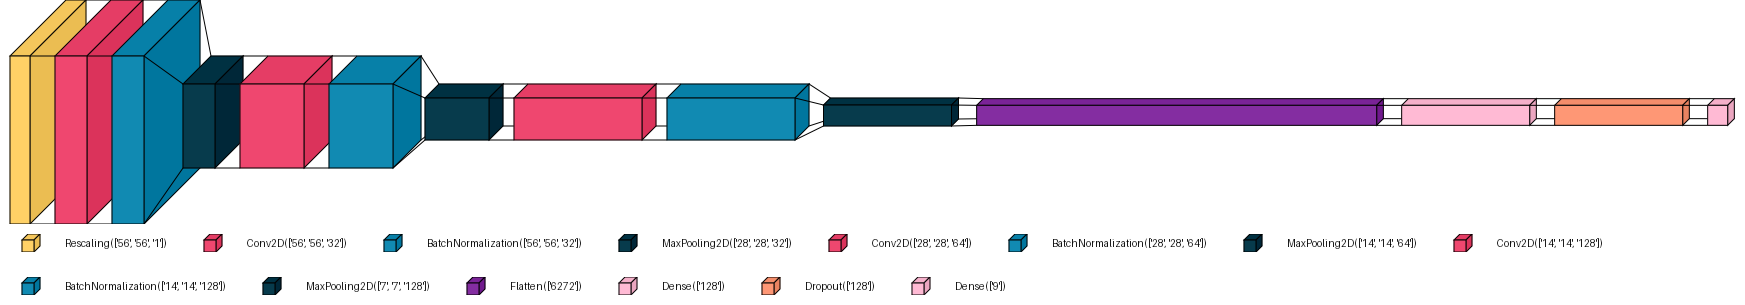

Architecture diagram with dimensions saved to: C:\Users\lollo\Documents\GitHub\deep-learning-wafer-defects\presentation_outputs\figures\cnn_architecture_shapes.png


In [12]:
architecture_shapes_path = (
    FIGURES_DIR
    / "cnn_architecture_shapes.png"
)

architecture_shapes = visualkeras.layered_view(
    full_architecture_model,
    legend=True,
    draw_volume=True,
    scale_xy=3,
    scale_z=1,
    spacing=25,
    show_dimension=True,
    to_file=str(architecture_shapes_path),
)

display(architecture_shapes)

print(
    "Architecture diagram with dimensions saved to: "
    f"{architecture_shapes_path}"
)

## Generated outputs

The notebook generates comparison tables and presentation-ready figures without modifying the experiment checkpoints or test results.

In [13]:
generated_files = pd.DataFrame(
    {
        "Output": [
            "Consistency checks",
            "Selected-model comparison",
            "Test-performance figure",
            "CNN architecture",
            "CNN architecture with dimensions",
        ],
        "Path": [
            consistency_output_path.relative_to(
                REPO_ROOT
            ).as_posix(),
            comparison_output_path.relative_to(
                REPO_ROOT
            ).as_posix(),
            comparison_figure_path.relative_to(
                REPO_ROOT
            ).as_posix(),
            architecture_hd_path.relative_to(
                REPO_ROOT
            ).as_posix(),
            architecture_shapes_path.relative_to(
                REPO_ROOT
            ).as_posix(),
        ],
    }
)

display(generated_files)

,Output,Path
0,Consistency checks,presentation_outputs/tables/experiment_consist...
1,Selected-model comparison,presentation_outputs/tables/selected_model_com...
2,Test-performance figure,presentation_outputs/figures/selected_model_te...
3,CNN architecture,presentation_outputs/figures/cnn_architecture_...
4,CNN architecture with dimensions,presentation_outputs/figures/cnn_architecture_...
